In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fit_literature import load_data, find_nearest
from attenuation_curves import Att_Curve_2param, Li_08_fit_noratio
from tqdm import tqdm

In [32]:
# Load the results from the CSV file
df = pd.read_csv("../data/galaxy_optimization_results.csv")

# Display the first few rows of the dataframe
df.head()

,gal_id,los,popt_2par,popt_4par,rmse_2par,rmse_4par,success_2par,success_4par
0,524576.0,28.0,[3.10691073 0.28572879],[-1.31414011e+02 2.11700183e+00 2.88624366e+...,0.056120,0.049480,True,True
1,524576.0,4.0,[10.87124965 -0.6310909 ],[ 8.83089453e+02 -2.03031809e+00 2.40908142e+...,0.692568,0.202755,True,True
2,524576.0,35.0,[2.71503088 0.01499929],[1.03470538e+02 1.06318786e+01 1.23909991e+02 ...,0.050530,0.043645,True,True
3,524576.0,19.0,[ 3.64327762 -0.03952779],[8.27278523e+02 1.20775544e+01 1.16588696e+03 ...,0.072153,0.051383,True,True
4,683079.0,39.0,[ 8.7319543 -0.65793098],[ 1.17742227e+02 -1.87127124e+00 8.14950398e+...,0.369736,0.236951,True,True


Print convergence statistics

In [33]:
success_2par = df['success_2par'].values
success_4par = df['success_4par'].values

print("Fraction of successful 2-parameter fits:", np.sum(success_2par) / len(success_2par))
print("Fraction of successful 4-parameter fits:", np.sum(success_4par) / len(success_4par))

Fraction of successful 2-parameter fits: 1.0
Fraction of successful 4-parameter fits: 1.0


Plot the distribution of RMSE for 2-parameter and 4-parameter fits

Total RMSE for 2-parameter fit: 0.5705383103280697
Total RMSE for 4-parameter fit: 0.21207178994036746


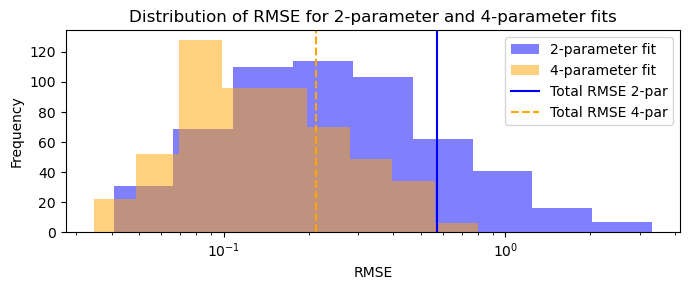

In [34]:
fig, ax = plt.subplots(figsize=(7, 3))
bins = np.logspace(np.log10(df['rmse_2par'].min()), np.log10(df['rmse_2par'].max()), num=10)
ax.hist(df['rmse_2par'], bins=bins, alpha=0.5, label='2-parameter fit', color='blue')
bins = np.logspace(np.log10(df['rmse_4par'].min()), np.log10(df['rmse_4par'].max()), num=10)
ax.hist(df['rmse_4par'], bins=bins, alpha=0.5, label='4-parameter fit', color='orange')

# Get aggregated RMSE. Each galaxy should have the same lambdas
total_rmse_2par = np.sqrt(np.mean(df['rmse_2par'] ** 2))
ax.axvline(total_rmse_2par, color='blue', linestyle='-', label='Total RMSE 2-par')
total_rmse_4par = np.sqrt(np.mean(df['rmse_4par'] ** 2))
ax.axvline(total_rmse_4par, color='orange', linestyle='--', label='Total RMSE 4-par')
print(f"Total RMSE for 2-parameter fit: {total_rmse_2par}")
print(f"Total RMSE for 4-parameter fit: {total_rmse_4par}")

ax.set_xlabel('RMSE')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of RMSE for 2-parameter and 4-parameter fits')
ax.legend()
ax.set_xscale('log')
fig.tight_layout()

Plot some example curves

In [35]:
def string_to_list(s):
    """
    Convert a string representation of a list to an actual list.
    """
    # Remove brackets and convert
    cleaned = s.strip('[]')
    return np.fromstring(cleaned, sep=' ').tolist()

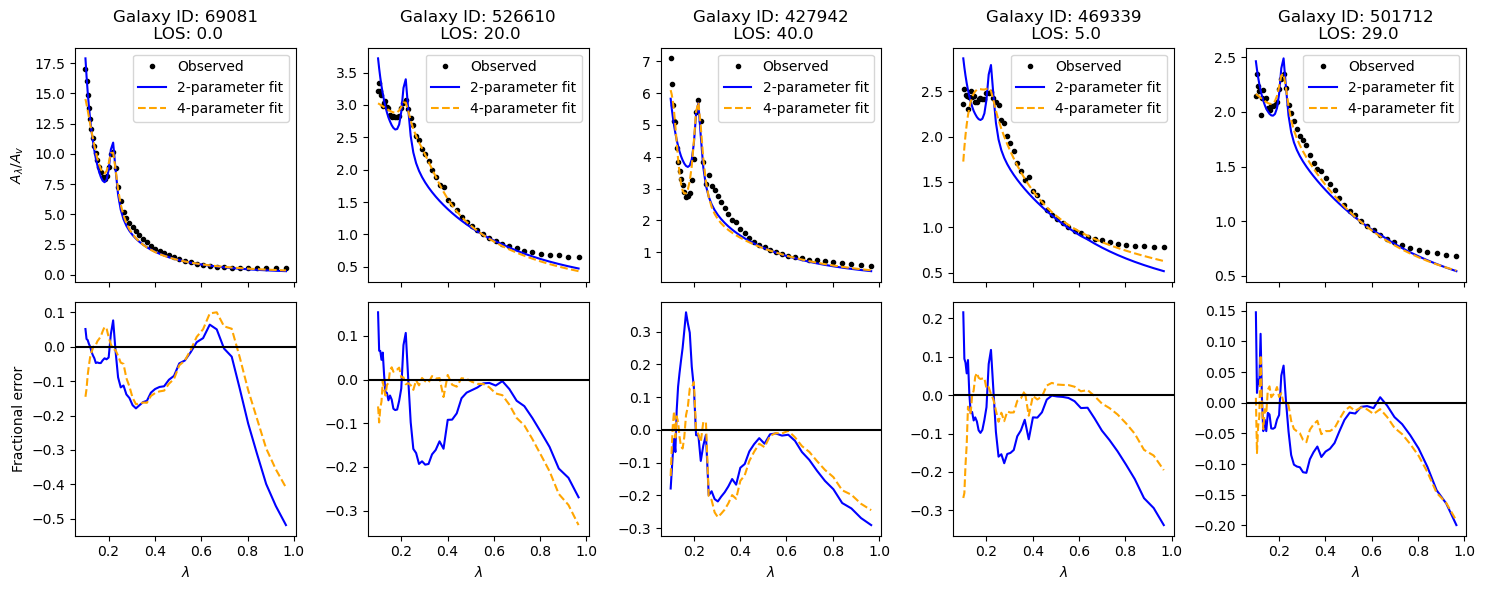

In [36]:
ngal = 5
ids, att_groups, attenuation_cols, lam_arr = load_data('../data/gal_los_iobcomp_attcurve_galprop.dat')

# Randomly select ngal galaxies from df['gal_id']
selected_ids = np.random.choice(df['gal_id'].unique(), size=ngal, replace=False)

fig, axs = plt.subplots(2, ngal, figsize=(3 * ngal, 6), sharex=True)

for i, gal_id in enumerate(selected_ids):
    group = att_groups.get_group(gal_id)

    # Randomly select a los
    los = group['los'].values
    los_idx = np.random.choice(len(los))
    los = los[los_idx]

    # Get the attenuation values for the selected los
    row = group[group['los'] == los]
    Alam_arr_cut = row[attenuation_cols].values.flatten()

    ### Normalising ad A_lambda to Av
    v_index = find_nearest(lam_arr,0.551)
    Av = Alam_arr_cut[v_index]
    Alam_Av_arr_cut = Alam_arr_cut/Av
    lam_cut = lam_arr[lam_arr < 1.]

    # Get the parameetrs for the 2-parameter and 4-parameter fits for this galaxy and los
    # Must convert to list
    group = df[df['gal_id'] == gal_id]
    row = group[group['los'] == los]
    popt_2par = string_to_list(row['popt_2par'].values.flatten()[0])
    popt_4par = string_to_list(row['popt_4par'].values.flatten()[0])
    rmse_2par = row['rmse_2par'].values.flatten().tolist()
    rmse_4par = row['rmse_4par'].values.flatten().tolist()
    fit_4par = Li_08_fit_noratio(lam_cut, *popt_4par)
    fit_2par = Att_Curve_2param(1e4*lam_cut, *popt_2par)
    rmse = np.sqrt(np.mean((Alam_Av_arr_cut - fit_2par) ** 2))
    assert np.isclose(rmse, rmse_2par), f"RMSE mismatch for 2-parameter fit: {rmse} vs {rmse_2par}"
    m = lam_cut>0.12
    rmse = np.sqrt(np.mean((Alam_Av_arr_cut[m] - fit_4par[m]) ** 2))
    assert np.isclose(rmse, rmse_4par), f"RMSE mismatch for 4-parameter fit: {rmse} vs {rmse_4par}"

    # Plot the results
    axs[0,i].plot(lam_cut, Alam_Av_arr_cut, 'o', label='Observed', markersize=3, color='k')
    axs[0,i].plot(lam_cut, fit_2par, label='2-parameter fit', color='blue', ls='-')
    axs[0,i].plot(lam_cut, fit_4par, label='4-parameter fit', color='orange', ls='--')
    axs[1,i].plot(lam_cut, fit_2par / Alam_Av_arr_cut - 1, label='2-parameter fit', color='blue', ls='-')
    axs[1,i].plot(lam_cut, fit_4par / Alam_Av_arr_cut - 1, label='4-parameter fit', color='orange', ls='--')
    axs[0,i].set_title(f'Galaxy ID: {int(gal_id)}\n LOS: {los}')
    axs[0,i].legend()
    axs[1,i].set_xlabel(r'$\lambda$')
    axs[1,i].axhline(0, color='k', ls='-')
axs[0,0].set_ylabel(r'$A_\lambda / A_v$')
axs[1,0].set_ylabel(r'Fractional error')
fig.align_labels()
fig.tight_layout()

Analyse error distribution as a function of wavelength

100%|██████████| 554/554 [00:00<00:00, 1599.00it/s]


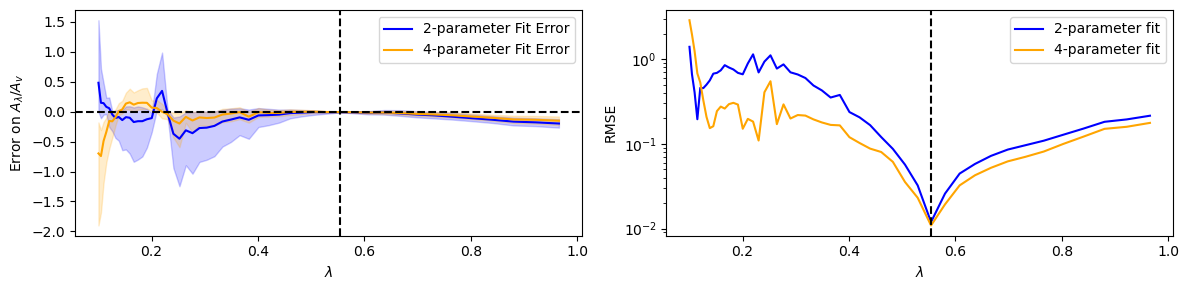

In [37]:
ids, att_groups, attenuation_cols, lam_arr = load_data('../data/gal_los_iobcomp_attcurve_galprop.dat')

err_2par = np.zeros((len(df['gal_id']), len(lam_arr)))
err_4par = np.zeros((len(df['gal_id']), len(lam_arr)))

do_fractional_error = True
do_fractional_error = False  # Set to True if you want fractional error

for i in tqdm(range(len(df['gal_id']))):
    
    popt_2par = string_to_list(df['popt_2par'].iloc[i])
    popt_4par = string_to_list(df['popt_4par'].iloc[i])
    gal_id = df['gal_id'].iloc[i]
    los = df['los'].iloc[i]

    # Get the attenuation values for the selected los
    group = att_groups.get_group(gal_id)
    row = group[group['los'] == los]
    Alam_arr_cut = row[attenuation_cols].values.flatten()

    # Normalising ad A_lambda to Av
    v_index = find_nearest(lam_arr,0.551)
    Av = Alam_arr_cut[v_index]
    Alam_Av_arr_cut = Alam_arr_cut/Av
    lam_cut = lam_arr[lam_arr < 1.]
    
    fit_4par = Li_08_fit_noratio(lam_cut, *popt_4par)
    fit_2par = Att_Curve_2param(1e4*lam_cut, *popt_2par)

    if do_fractional_error:
        err_2par[i, :len(lam_cut)] = fit_2par / Alam_Av_arr_cut - 1
        err_4par[i, :len(lam_cut)] = fit_4par / Alam_Av_arr_cut - 1
    else:
        err_2par[i, :len(lam_cut)] = fit_2par - Alam_Av_arr_cut
        err_4par[i, :len(lam_cut)] = fit_4par - Alam_Av_arr_cut

err_2par = err_2par[:, :len(lam_cut)]
err_4par = err_4par[:, :len(lam_cut)]

fig, axs = plt.subplots(1, 2, figsize=(12, 3))
axs[0].plot(lam_cut, np.median(err_2par, axis=0), label='2-parameter Fit Error', color='blue')
axs[0].fill_between(lam_cut, 
                    np.percentile(err_2par, 16, axis=0), 
                    np.percentile(err_2par, 84, axis=0), 
                    color='blue', alpha=0.2)
if do_fractional_error:
    axs[0].set_ylabel(r'Fractional Error on $A_\lambda / A_v$')
else:
    axs[0].set_ylabel(r'Error on $A_\lambda / A_v$')
rmse = np.sqrt(np.mean(err_2par ** 2, axis=0))
m = rmse > 0
axs[1].semilogy(lam_cut[m], rmse[m], label='2-parameter fit', color='blue')

axs[0].plot(lam_cut, np.median(err_4par, axis=0), label='4-parameter Fit Error', color='orange')
axs[0].fill_between(lam_cut, 
                    np.percentile(err_4par, 16, axis=0), 
                    np.percentile(err_4par, 84, axis=0), 
                    color='orange', alpha=0.2,)
rmse = np.sqrt(np.mean(err_4par ** 2, axis=0))
m = rmse > 0
axs[1].semilogy(lam_cut[m], rmse[m], label='4-parameter fit', color='orange')

axs[0].axhline(0, color='black', ls='--')

for ax in axs:
    ax.legend()
    ax.axvline(lam_arr[v_index], color='black', ls='--')
    ax.set_xlabel(r'$\lambda$')

if do_fractional_error:
    axs[1].set_ylabel('RMS of Fractional Error')
else:
    axs[1].set_ylabel('RMSE')

fig.align_labels()
fig.tight_layout()
